In [ ]:
!pip install -q tensorflow opencv-python matplotlib scikit-learn kagglehub


In [ ]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import kagglehub


In [ ]:
path = kagglehub.dataset_download("manjilkarki/deepfake-and-real-images")
print("Dataset path:", path)


100%|██████████| 1.68G/1.68G [01:11<00:00, 25.2MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1


In [ ]:
TRAIN_DIR = f"{path}/Dataset/Train"
TEST_DIR  = f"{path}/Dataset/Test"

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16  # small batch = low RAM usage

LAPTOP_MODE = False  # Set to True for quick CPU laptop tests. Set to False for full training (as shown below).

train_gen = ImageDataGenerator(
    # rescale=1./255,  # REMOVED: EfficientNet has built-in rescaling. Double rescaling ruins training!
    validation_split=0.2
)

test_gen = ImageDataGenerator()  # REMOVED rescale=1./255


In [ ]:
import os

print(f"Contents of {path}:\n{os.listdir(path)}")

# If 'Dataset' is listed, check its contents as well
if 'Dataset' in os.listdir(path):
    dataset_path = os.path.join(path, 'Dataset')
    print(f"Contents of {dataset_path}:\n{os.listdir(dataset_path)}")

train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_data = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Contents of /root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1:
['Dataset']
Contents of /root/.cache/kagglehub/datasets/manjilkarki/deepfake-and-real-images/versions/1/Dataset:
['Test', 'Validation', 'Train']
Found 112002 images belonging to 2 classes.
Found 28000 images belonging to 2 classes.
Found 10905 images belonging to 2 classes.


In [ ]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(weights))
print("Class Weights:", class_weights)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    class_weight=class_weights
)


Class Weights: {0: np.float64(1.0), 1: np.float64(1.0)}
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7001/7001 ━━━━━━━━━━━━━━━━━━━━ 268s 35ms/step - accuracy: 0.4986 - loss: 0.6957 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/5
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 214s 31ms/step - accuracy: 0.4976 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/5
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 263s 31ms/step - accuracy: 0.5005 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/5
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 213s 30ms/step - accuracy: 0.5002 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/5
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 217s 31ms/step - accuracy: 0.5004 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931


In [ ]:
y_pred_prob = model.predict(test_data).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)
y_true = test_data.classes


In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print("ROC-AUC:", roc_auc_score(y_true, y_pred_prob))


Accuracy: 0.5102246675836772
ROC-AUC: 0.6643952428193086


In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Fake", "Real"])
disp.plot(cmap="Blues")
plt.show()


In [ ]:
def predict_and_show_percentage(img_path):
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Load image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not load image from {img_path}")
        return
        
    # Convert BGR to RGB for visualization and network consistency
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Preprocess image (resize to 224x224, keep raw [0, 255] scale to match fixed EfficientNet)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_batch = np.expand_dims(img_resized, axis=0)
    
    # Predict probability of Real (class 1)
    pred_prob = model.predict(img_batch)[0][0]
    
    # Calculate percentages
    real_prob = pred_prob * 100
    fake_prob = (1 - pred_prob) * 100
    
    # Determine final prediction (class 0 is Fake, class 1 is Real)
    final_pred = "Real" if pred_prob > 0.5 else "Fake"
    
    # Print results in the expected format
    print(f"Fake Probability : {fake_prob:.2f}%")
    print(f"Real Probability : {real_prob:.2f}%")
    print(f"Final Prediction : {final_pred}")
    
    # Display the image
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()


In [ ]:
print(train_data.class_indices)


{'Fake': 0, 'Real': 1}


In [ ]:
print(os.listdir(f"{TEST_DIR}/Fake")[:5])
print(os.listdir(f"{TEST_DIR}/Real")[:5])

['fake_2469.jpg', 'fake_4996.jpg', 'fake_4181.jpg', 'fake_2.jpg', 'fake_2993.jpg']
['real_3844.jpg', 'real_165.jpg', 'real_2767.jpg', 'real_299.jpg', 'real_4684.jpg']


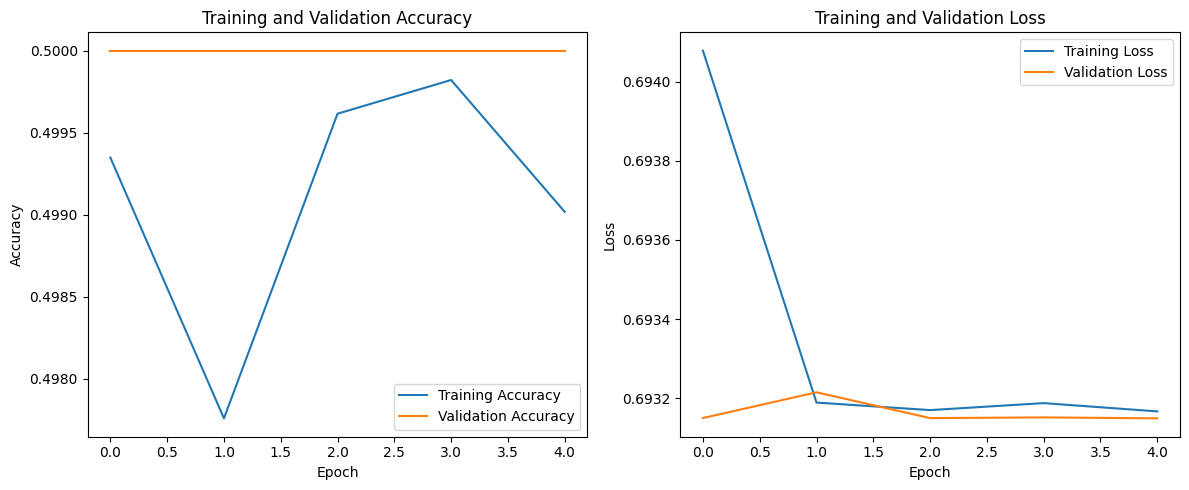

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:150]:
    layer.trainable = False

print(f"Number of trainable layers in base model: {len([layer for layer in base_model.layers if layer.trainable])}")

Number of trainable layers in base model: 30


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled with a lower learning rate.")

Model recompiled with a lower learning rate.


In [ ]:
fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weights
)
print("Model fine-tuning complete for 10 epochs.")

Epoch 1/10
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 285s 37ms/step - accuracy: 0.5930 - loss: 0.6570 - val_accuracy: 0.5088 - val_loss: 0.8993
Epoch 2/10
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 239s 34ms/step - accuracy: 0.6019 - loss: 0.6506 - val_accuracy: 0.5261 - val_loss: 0.7904
Epoch 3/10
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 239s 34ms/step - accuracy: 0.6086 - loss: 0.6473 - val_accuracy: 0.6551 - val_loss: 0.6166
Epoch 4/10
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 235s 34ms/step - accuracy: 0.6125 - loss: 0.6427 - val_accuracy: 0.6060 - val_loss: 0.6437
Epoch 5/10
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 238s 34ms/step - accuracy: 0.6188 - loss: 0.6408 - val_accuracy: 0.6344 - val_loss: 0.6231
Epoch 6/10
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 238s 34ms/step - accuracy: 0.6230 - loss: 0.6366 - val_accuracy: 0.6781 - val_loss: 0.6005
Epoch 7/10
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 234s 33ms/step - accuracy: 0.6283 - loss: 0.6332 - val_accuracy: 0.6801 - val_loss: 0.5975
Epoch 8/10
7001/7001 ━━━━━━━━━━━━━━━━━━━━ 237s 34ms/step - accuracy: 

682/682 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step
Retrained Model Evaluation:
Accuracy: 0.6581384685923888
ROC-AUC: 0.7187078724857708


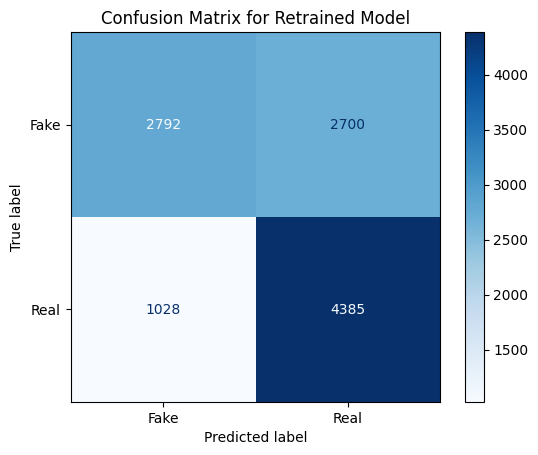

In [ ]:
y_pred_prob_retrained = model.predict(test_data).ravel()
y_pred_retrained = (y_pred_prob_retrained > 0.5).astype(int)
y_true_retrained = test_data.classes

print("Retrained Model Evaluation:")
print("Accuracy:", accuracy_score(y_true_retrained, y_pred_retrained))
print("ROC-AUC:", roc_auc_score(y_true_retrained, y_pred_prob_retrained))

cm_retrained = confusion_matrix(y_true_retrained, y_pred_retrained)
disp_retrained = ConfusionMatrixDisplay(cm_retrained, display_labels=["Fake", "Real"])
disp_retrained.plot(cmap="Blues")
plt.title("Confusion Matrix for Retrained Model")
plt.show()

Verifying with a sample Fake image:
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


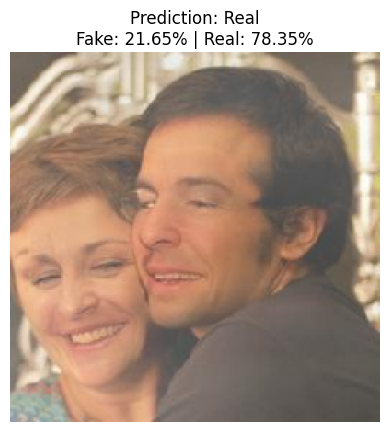

Fake Probability : 21.65%
Real Probability : 78.35%
Final Prediction : Real

Verifying with a sample Real image:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


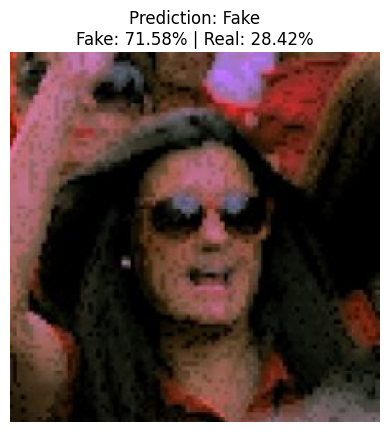

Fake Probability : 71.58%
Real Probability : 28.42%
Final Prediction : Fake


In [ ]:
print("Verifying with a sample Fake image:")
fake_image_path = os.path.join(TEST_DIR, "Fake", os.listdir(f"{TEST_DIR}/Fake")[0])
predict_and_show_percentage(fake_image_path)

print("\nVerifying with a sample Real image:")
real_image_path = os.path.join(TEST_DIR, "Real", os.listdir(f"{TEST_DIR}/Real")[0])
predict_and_show_percentage(real_image_path)

Saving download2.jfif to download2.jfif
Uploaded image: download2.jfif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


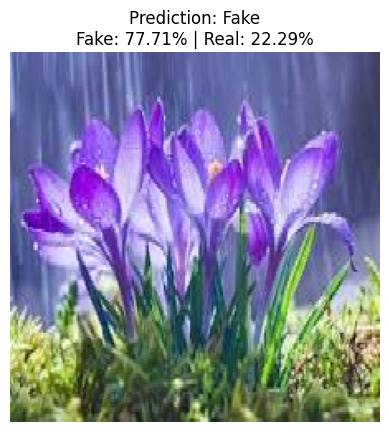

Fake Probability : 77.71%
Real Probability : 22.29%
Final Prediction : Fake


In [ ]:
try:
    from google.colab import files
    uploaded = files.upload()
    # Get the path of the uploaded image
    image_path_custom = list(uploaded.keys())[0]
    print("Uploaded image:", image_path_custom)
except ImportError:
    # Fallback for running locally on your laptop
    print("Running locally on your laptop.")
    image_path_custom = input("Please paste the absolute path to your test image: ").strip().strip('"\'')

if image_path_custom:
    # Make prediction on the custom image
    predict_and_show_percentage(image_path_custom)
